In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [83]:
import os
import random
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm

In [84]:
data_dir = "/kaggle/input/cats-and-dogs-image-classification/train"

In [85]:
class SiameseCatsDogsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        cat_dir = os.path.join(root_dir, "cats")
        dog_dir = os.path.join(root_dir, "dogs")

        self.cat_images = [
            os.path.join(cat_dir, img)
            for img in os.listdir(cat_dir)
            if os.path.isfile(os.path.join(cat_dir, img))
        ]
        self.dog_images = [
            os.path.join(dog_dir, img)
            for img in os.listdir(dog_dir)
            if os.path.isfile(os.path.join(dog_dir, img))
        ]
        self.all_images = self.cat_images + self.dog_images

        print(f"Loaded {len(self.cat_images)} cat images and {len(self.dog_images)} dog images.")

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, idx):
        img1_path = self.all_images[idx]
        label1 = 0 if img1_path in self.cat_images else 1
        img1 = Image.open(img1_path).convert("L")

        should_match = random.randint(0, 1)
        if should_match:
            img2_path = random.choice(self.cat_images if label1 == 0 else self.dog_images)
        else:
            img2_path = random.choice(self.dog_images if label1 == 0 else self.cat_images)

        label2 = 0 if img2_path in self.cat_images else 1
        img2 = Image.open(img2_path).convert("L")
        label = torch.tensor([int(label1 == label2)], dtype=torch.float32)

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

In [86]:
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [87]:
import os

data_dir = "/kaggle/input/cats-and-dogs-image-classification/test"  # Make sure this is correct

# Check: Does the path exist?
print("Exists:", os.path.exists(data_dir))

# Check: List files in directory
print("Files in directory:", os.listdir(data_dir))

# Optional: Check if any files contain "cat" or "dog"
print("Cat images:", [f for f in os.listdir(data_dir) if "cat" in f.lower()])
print("Dog images:", [f for f in os.listdir(data_dir) if "dog" in f.lower()])


Exists: True
Files in directory: ['dogs', 'cats']
Cat images: ['cats']
Dog images: ['dogs']


In [88]:
dataset = SiameseCatsDogsDataset(data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


Loaded 70 cat images and 70 dog images.


In [89]:
class SiameseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 100 -> 50

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 50 -> 25

            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)  # 25 -> 12
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 12 * 12, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward_once(self, x):
        return self.fc(self.cnn(x))

    def forward(self, x1, x2):
        emb1 = self.forward_once(x1)
        emb2 = self.forward_once(x2)
        return F.pairwise_distance(emb1, emb2)


(Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)), ReLU())

In [90]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SiameseNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
     


def contrastive_loss(dist, label, margin=1.0):
    # label = 1 for same, 0 for different
    loss_same = label * torch.pow(dist, 2)
    loss_diff = (1 - label) * torch.pow(torch.clamp(margin - dist, min=0.0), 2)
    return torch.mean(loss_same + loss_diff)

# Train for 1 epoch (you can increase it)
for epoch in range(25):
    model.train()
    running_loss = 0.0
    for img1, img2, label in tqdm(dataloader):
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        dist = model(img1, img2)
        loss = contrastive_loss(dist, label).mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1} Loss: {running_loss/len(dataloader):.4f}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 Loss: 0.4313


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 2 Loss: 0.3508


  0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 23 Loss: 0.2616


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 24 Loss: 0.2719


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 25 Loss: 0.2667


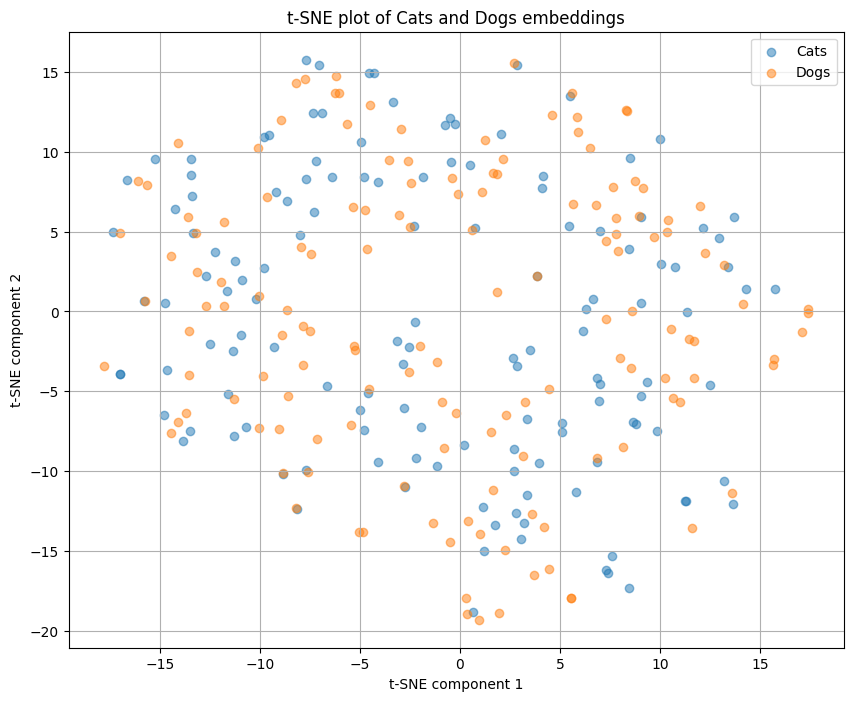

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Function to extract embeddings
def extract_embeddings(dataloader, model, device):
    model.eval()
    embeddings = []
    labels = []
    with torch.no_grad():
        for img1, img2, label in dataloader:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            emb1 = model.forward_once(img1)
            emb2 = model.forward_once(img2)
            embeddings.append(emb1.cpu().numpy())
            embeddings.append(emb2.cpu().numpy())
            labels.append(label.cpu().numpy())
            labels.append(label.cpu().numpy())
    embeddings = np.concatenate(embeddings)
    labels = np.concatenate(labels).flatten()
    return embeddings, labels

# Extract embeddings and labels
embeddings, labels = extract_embeddings(dataloader, model, device)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot t-SNE
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[labels == 0][:, 0], embeddings_2d[labels == 0][:, 1], label='Cats', alpha=0.5)
plt.scatter(embeddings_2d[labels == 1][:, 0], embeddings_2d[labels == 1][:, 1], label='Dogs', alpha=0.5)
plt.legend()
plt.title('t-SNE plot of Cats and Dogs embeddings')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.grid(True)
plt.show()
